# <ins>**You've Got Mail! Analysing The Efficiency of a Feedforward Neural Network in Detecting Spam Emails.**</ins>

## <ins> Rationale </ins>

It is fairly common for organisations to be at risk of receiving spam emails. Many email services such as Microsoft or Google incorporate AI spam filters into their services to prevent spam from reaching its intended recipient. These spam filters need to score highly across:

<ul>
    <li>Accuracy: Predicting spam and non-spam overall.</li>
    <li>Precision: Identifying spam and not incorrectly labelling non-spam as spam (false positive).</li>
    <li>Recall: Labelling spam and not incorrectly labelling spam as non-spam (false negatives).</li>
</ul>

With recent advancements in machine learning (specifically deep learning), this project aims to test how efficient a basic feedforward neural network is at identifying spam mail.

The data for this project uses the UC Irvine (UCI) Machine Learning Repository's Spambase dataset. This data is a collection of emails marked as either spam or not. There are various predictors measuring the average frequency of specific words, and the lengths of sequences consisting of solely captial letters. 

## <ins> Data Collection </ins>

### <ins> Dependent Variable </ins>

In [20]:
# Imports relevant libraries.
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model

import pydot
import graphviz

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [ ]:
spam_data = fetch_ucirepo(id=94)

### <ins> Preprocessing </ins>

In [ ]:
data_frame = spam_data["data"]["features"]
data_frame["outcome"] = spam_data["data"]["targets"]

In [ ]:
np.where(data_frame.isnull().sum()), data_frame.duplicated().sum()

((array([], dtype=int64),), np.int64(391))

In [ ]:
# Drops the duplicates found
data_frame = data_frame.drop_duplicates()

In [ ]:
# Puts outcome into its own frame.
y_frame = data_frame[["outcome"]]
data_frame = data_frame.drop(columns=["outcome"])

In [ ]:
y_frame.describe()

,outcome
count,4210.000000
mean,0.398812
std,0.489712
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


Around 39% of the emails were spam (binary outcomes so mean=proportion).

In [ ]:
# Check missing outcomes.
y_frame.isnull().sum()

outcome    0
dtype: int64

In [ ]:
# Flattens into numpy array
y = np.array(y_frame)
y = y.flatten()

### <ins> Data Train and Test Split </ins>

For this project the data was split 80/20 for training-testing. As machine learning models are sensitive to the scale of the input features, the data was standardised using sci-kit learn's StandardScaler. 

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data_frame,y,test_size=0.2,random_state=5, stratify=y)

train_array = np.array(x_train)
test_array = np.array(x_test)

scaler = StandardScaler()
train_array = scaler.fit_transform(train_array)
test_array = scaler.transform(test_array)

In [ ]:
train_array.ndim, train_array.shape

(2, (3368, 58))

Both the training arrays (feature training and outcome training) the model were then ready to be given to the model.

## <ins> Feedforward Spam Identification Model </ins>

In [ ]:
model = keras.Sequential([
    layers.Dense(32, activation="relu",name="hidden_layer"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid",name="output_layer")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy","precision", "recall"])

One hidden layer was added consisting of 32 nodes. Relu was used as an activation function to ensure negative values were returned as zero. Then a dropout layer was also used to reduce overfitting, and improve generalisation. The output layers used a sigmoid function to return the output as a probability.

Adaptive Moment Estimation (Adam) was used as the learning rate algorithm due to its robustness. Binary cross-entropy is often efficient for calibrating outputs on a binary scale.

### <ins>Model Training</ins>

In [ ]:
fitted_model = model.fit(
    train_array,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, min_delta=0.003, restore_best_weights=True)]
    )

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6481 - loss: 0.6956 - precision: 0.5381 - recall: 0.6676 - val_accuracy: 0.8457 - val_loss: 0.4455 - val_precision: 0.8478 - val_recall: 0.7905
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8615 - loss: 0.4071 - precision: 0.8357 - recall: 0.8013 - val_accuracy: 0.9080 - val_loss: 0.3097 - val_precision: 0.9366 - val_recall: 0.8480
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9031 - loss: 0.3038 - precision: 0.8954 - recall: 0.8500 - val_accuracy: 0.9347 - val_loss: 0.2422 - val_precision: 0.9532 - val_recall: 0.8953
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9284 - loss: 0.2413 - precision: 0.9287 - recall: 0.8835 - val_accuracy: 0.9466 - val_loss: 0.1923 - val_precision: 0.9514 - val_recall: 0.9257
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9425 - loss: 0.1973 - precision: 0.9339 - recall: 0.9169 - val_accuracy: 0.9599 - val_loss: 0.1578

### <ins> Metrics </ins>

Metrics for the models performance on the test data were calculated:

In [ ]:
test_loss, test_acc, test_prec, test_recall = model.evaluate(test_array, y_test)
print(f"test_loss: {test_loss}")
print(f"test_acc: {test_acc}")
print(f"test_precision: {test_prec}")
print(f"test_recall: {test_recall}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0075 - precision: 1.0000 - recall: 1.0000
test_loss: 0.007507591973990202
test_acc: 1.0
test_precision: 1.0
test_recall: 1.0


Test accuracy: The model was correct across all predictions over <b>99%*</b> of the time. This was higher than both the baseline model performance for a XGboost classification model (~95.92%) and the expected neural network classification point estimate (~91.49%).

Test precision: Regarding correct spam predictions, the model correctly identified true positives over <b>99%*</b> of the time. This was higher than the point estimate for the XGboost model (~95.68%) and the neural network models (~91.00%).

Test recall: The model correctly found over <b>99%*</b> of the spam emails. There were no comparisons for recall on the UCI website.

Overall, model performed effectively, scoring over 99% across the 3 metrics. It correctly identified more spam (true positives) and non-spam (true negatives) overall than the estimated point values for neural networks and XGBoost. Overall, this model appears appropriate for spam email detection.

<i><b>*Note</b>: the model was tested multiple times to ensure the metrics were consistent. As such, the values reported for the current model are approximations.</i>

### <ins> Confusion Matrix </ins>

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Text(0.5, 0, 'Predicted as Spam (1=Yes, 0=No)')

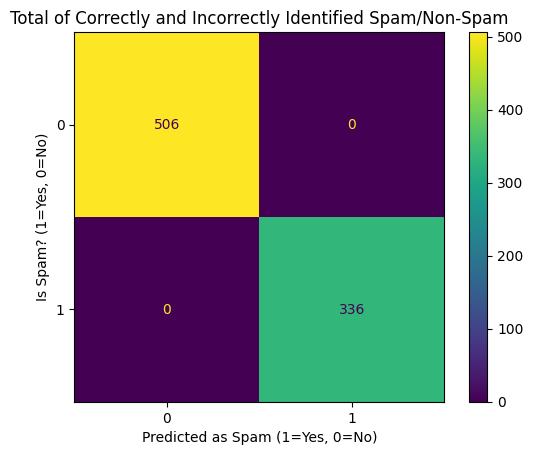

In [ ]:
predictions = model.predict(test_array)
predictions = tf.squeeze(predictions)
prob_arr = np.array([1 if x >= 0.5 else 0 for x in predictions])

cf = confusion_matrix(y_test, prob_arr)

disp_cf = ConfusionMatrixDisplay(confusion_matrix=cf)

disp_cf.plot()
disp_cf.ax_.set_title("Total of Correctly and Incorrectly Identified Spam/Non-Spam")
disp_cf.ax_.set_ylabel("Is Spam? (1=Yes, 0=No)")
disp_cf.ax_.set_xlabel("Predicted as Spam (1=Yes, 0=No)")

### <ins> Validation vs Training Loss </ins>

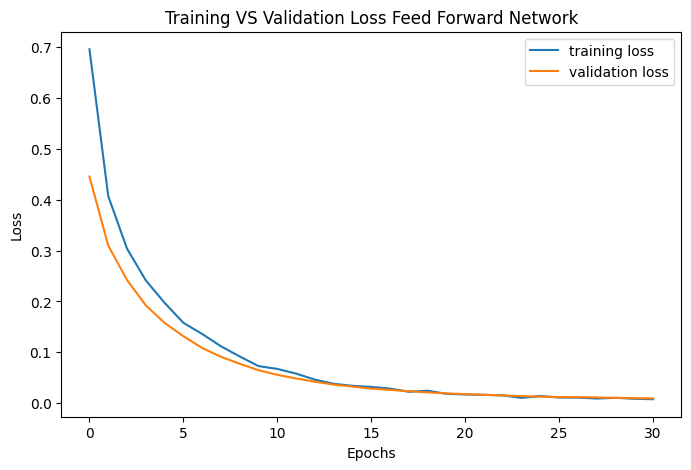

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(fitted_model.history["loss"],label="training loss")
plt.plot(fitted_model.history["val_loss"],label="validation loss")
plt.title("Training VS Validation Loss Feed Forward Network")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

The model fit the data well with no signs of over or underfitting.

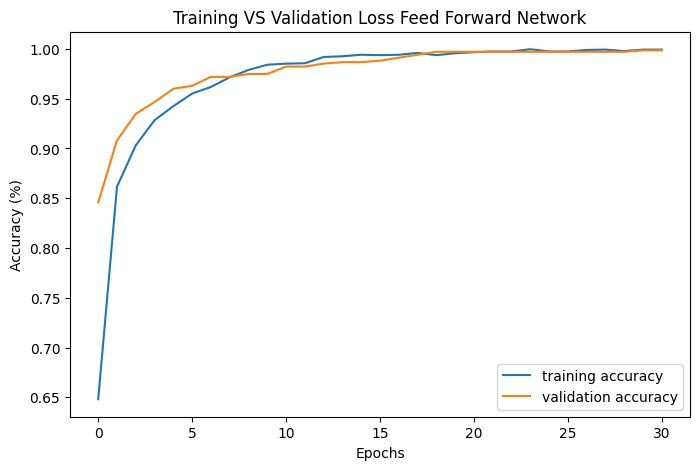

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(fitted_model.history["accuracy"],label="training accuracy")
plt.plot(fitted_model.history["val_accuracy"],label="validation accuracy")
plt.title("Training VS Validation Loss Feed Forward Network")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

## <ins> Network Plot</ins>

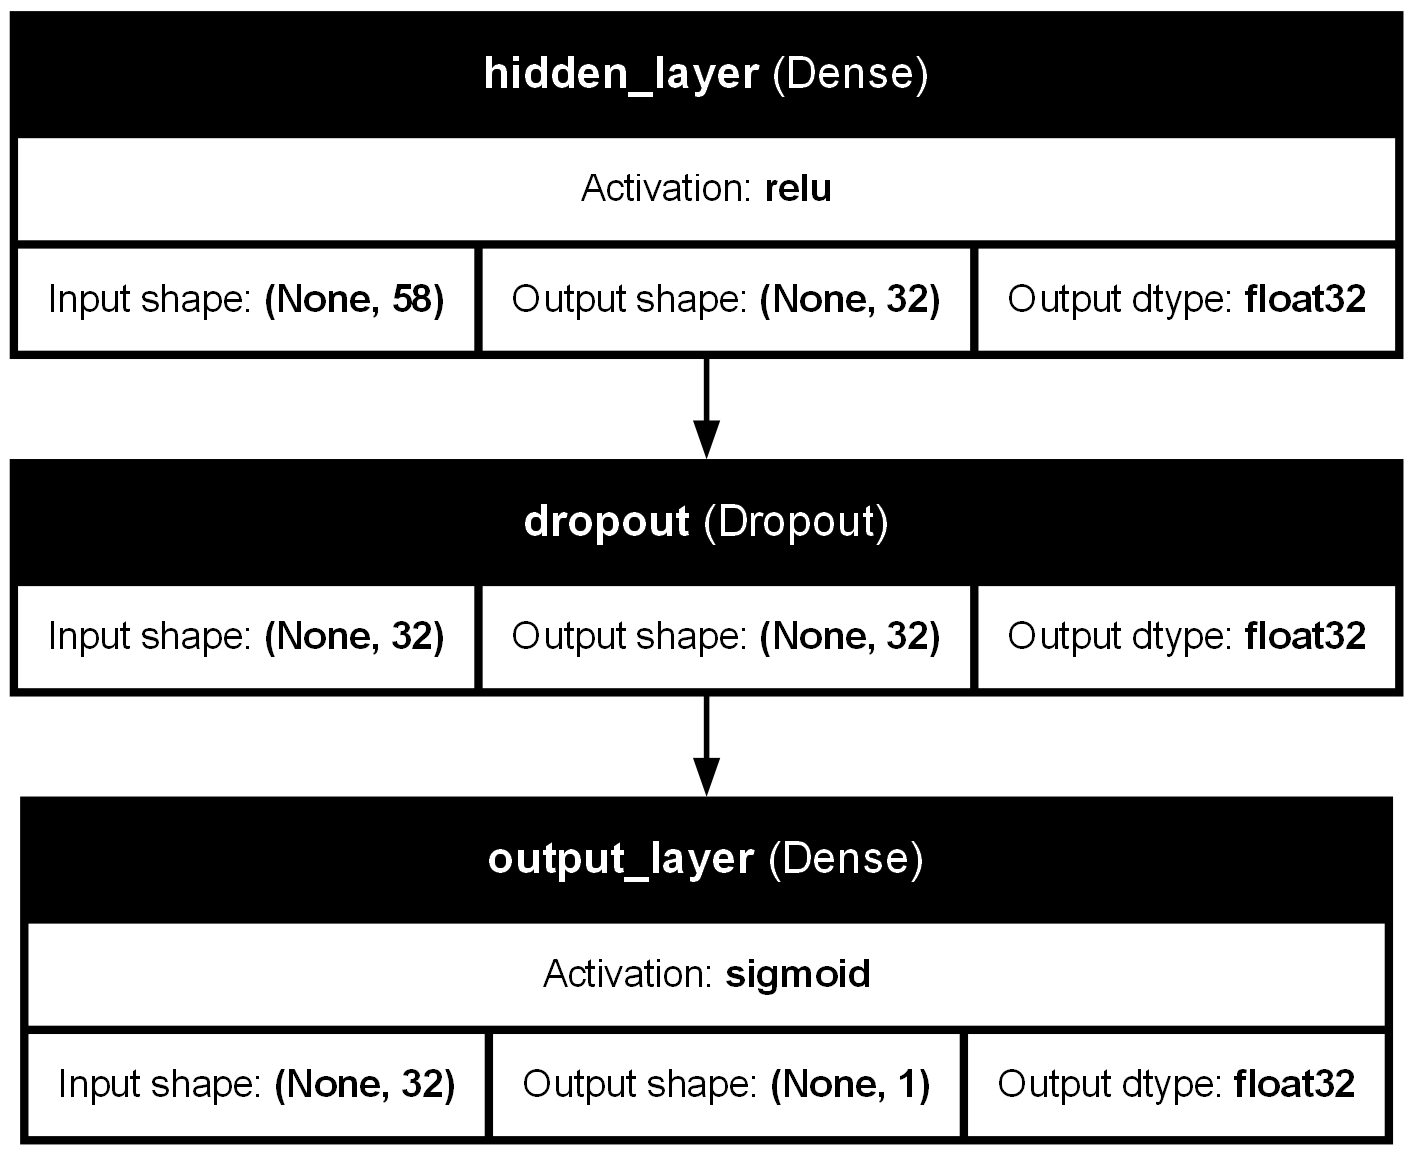

In [ ]:
plot_model(model,to_file="assets/ff_spam/model_vis.png",
           show_shapes=True,
           show_dtype=True,
           show_layer_names=True,
           show_layer_activations=True)

## <ins>Copyright</ins>

Link to the data: [https://archive.ics.uci.edu/dataset/94/spambase](https://archive.ics.uci.edu/dataset/94/spambase)